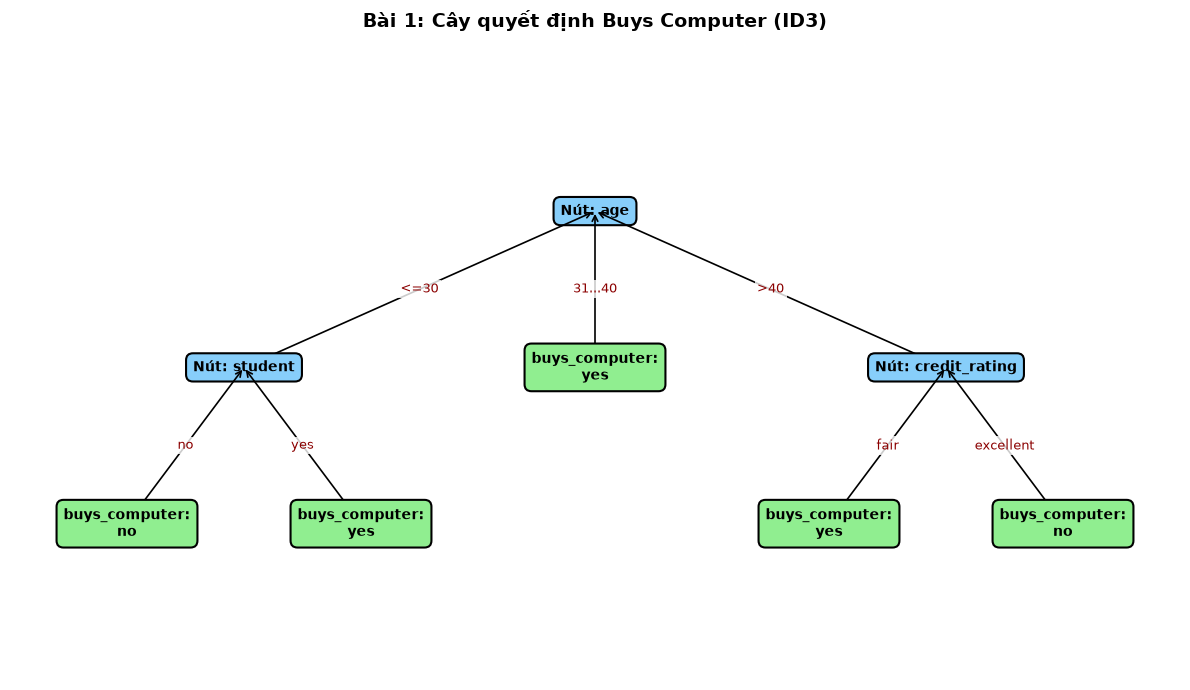

In [2]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. CÁC HÀM TÍNH ENTROPY & INFORMATION GAIN (ID3)
# ----------------------------------------------------
def calculate_entropy(df, target_col):
    total_count = len(df)
    if total_count == 0:
        return 0
    value_counts = df[target_col].value_counts()
    entropy = 0.0
    for count in value_counts:
        p = count / total_count
        entropy -= p * math.log2(p)
    return entropy

def gain_categorical(df, feature_col, target_col):
    base_entropy = calculate_entropy(df, target_col)
    total_count = len(df)
    weighted_entropy = 0.0
    for val, group in df.groupby(feature_col):
        prob = len(group) / total_count
        weighted_entropy += prob * calculate_entropy(group, target_col)
    return base_entropy - weighted_entropy

# ----------------------------------------------------
# 2. XÂY DỰNG CÂY QUYẾT ĐỊNH
# ----------------------------------------------------
class Node:
    def __init__(self, feature=None, is_leaf=False, value=None):
        self.feature = feature
        self.branches = {}
        self.is_leaf = is_leaf
        self.value = value

def build_tree(df, features, target_col):
    unique_targets = df[target_col].unique()
    if len(unique_targets) == 1:
        return Node(is_leaf=True, value=unique_targets[0])
    
    if len(features) == 0:
        most_common = df[target_col].mode()[0]
        return Node(is_leaf=True, value=most_common)
    
    best_feature = None
    best_gain = -1
    
    for col in features:
        gain = gain_categorical(df, col, target_col)
        if gain > best_gain:
            best_gain = gain
            best_feature = col
            
    if best_gain <= 0 or best_feature is None:
        most_common = df[target_col].mode()[0]
        return Node(is_leaf=True, value=most_common)
    
    node = Node(feature=best_feature)
    remaining_features = [f for f in features if f != best_feature]
    for val in df[best_feature].unique():
        sub_df = df[df[best_feature] == val]
        node.branches[val] = build_tree(sub_df, remaining_features, target_col)
            
    return node

# ----------------------------------------------------
# 3. HÀM VẼ CÂY BẰNG MATPLOTLIB
# ----------------------------------------------------
def get_tree_leaf_count(node):
    if node.is_leaf:
        return 1
    return sum(get_tree_leaf_count(child) for child in node.branches.values())

def get_tree_depth(node):
    if node.is_leaf:
        return 1
    return 1 + max(get_tree_depth(child) for child in node.branches.values())

def plot_node(ax, text, center_pt, parent_pt, edge_text, is_leaf=False):
    bbox_props = dict(boxstyle="round,pad=0.5", 
                      fc="#90ee90" if is_leaf else "#87cefa", 
                      ec="black", lw=1.5)
    if parent_pt:
        ax.annotate('', xy=center_pt, xycoords='axes fraction',
                    xytext=parent_pt, textcoords='axes fraction',
                    arrowprops=dict(arrowstyle="<-", color="black", lw=1.2))
        mid_x = (center_pt[0] + parent_pt[0]) / 2.0
        mid_y = (center_pt[1] + parent_pt[1]) / 2.0
        ax.text(mid_x, mid_y, edge_text, fontsize=9, color='darkred',
                ha='center', va='center', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none", alpha=0.8))

    ax.text(center_pt[0], center_pt[1], text, fontsize=10, fontweight='bold',
            ha='center', va='center', bbox=bbox_props)

def plot_tree_recursive(ax, node, parent_pt, edge_text, x_left, x_right, y, depth_step):
    x_center = (x_left + x_right) / 2.0
    current_pt = (x_center, y)

    if node.is_leaf:
        plot_node(ax, f"buys_computer:\n{node.value}", current_pt, parent_pt, edge_text, is_leaf=True)
        return

    text = f"Nút: {node.feature}"
    plot_node(ax, text, current_pt, parent_pt, edge_text)

    total_leaves = get_tree_leaf_count(node)
    current_x = x_left
    
    for val, child in node.branches.items():
        child_leaves = get_tree_leaf_count(child)
        next_x = current_x + (x_right - x_left) * (child_leaves / total_leaves)
        plot_tree_recursive(ax, child, current_pt, str(val), current_x, next_x, y - depth_step, depth_step)
        current_x = next_x

def draw_decision_tree(root, title="Cây quyết định ID3"):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.axis('off')
    depth = get_tree_depth(root)
    depth_step = 1.0 / (depth + 1)
    plot_tree_recursive(ax, root, None, "", 0.0, 1.0, 1.0 - depth_step, depth_step)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------
# 4. CHẠY BÀI 1
# ----------------------------------------------------
data_1 = {
    'age': ['<=30', '<=30', '31...40', '>40', '>40', '>40', '31...40', 
            '<=30', '<=30', '>40', '<=30', '31...40', '31...40', '>40'],
    'income': ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 
               'medium', 'low', 'medium', 'medium', 'medium', 'high', 'medium'],
    'student': ['no', 'no', 'no', 'no', 'yes', 'yes', 'yes', 
                'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no'],
    'credit_rating': ['fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 
                     'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'excellent'],
    'buys_computer': ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 
                      'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no']
}

df1 = pd.DataFrame(data_1)
features_1 = ['age', 'income', 'student', 'credit_rating']
tree_1 = build_tree(df1, features_1, 'buys_computer')

draw_decision_tree(tree_1, title="Bài 1: Cây quyết định Buys Computer (ID3)")